In [ ]:
!unzip /content/train.zip -d /content/train


Archive:  /content/train.zip
replace /content/train/train/images/1-1_jpg.rf.3c35c15f5361d33821647bfd181b0af7.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!unzip /content/test.zip -d /content/test


Archive:  /content/test.zip
replace /content/test/test/images/1bc7-iudfmpmn7245599_jpg.rf.c753c3518aa3bd30463da5e4b94a48be.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!unzip /content/valid.zip -d /content/valid


Archive:  /content/valid.zip
replace /content/valid/valid/images/007104744_jpg.rf.c471c6606dbf17f1e5bf3c3ad70d5661.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())


2.6.0+cu124
CUDA available: True


In [ ]:
import os

label_dir = "/content/train/train/labels"  # change this
image_dir = "/content/train/train/images"

for file in os.listdir(label_dir):
    label_path = os.path.join(label_dir, file)
    with open(label_path, "r") as f:
        lines = f.readlines()
    if len(lines) == 0:
        print(f"❌ Empty label: {file} — Removing file and image.")
        os.remove(label_path)
        image_name = file.replace(".txt", ".jpg")
        img_path = os.path.join(image_dir, image_name)
        if os.path.exists(img_path):
            os.remove(img_path)


100%|██████████| 454/454 [11:09<00:00,  1.47s/it]


Epoch 1: Loss = 204.7546


100%|██████████| 454/454 [11:16<00:00,  1.49s/it]


Epoch 2: Loss = 145.3708


100%|██████████| 454/454 [11:17<00:00,  1.49s/it]


...

Epoch 4: Loss = 110.7082


100%|██████████| 454/454 [11:16<00:00,  1.49s/it]


Epoch 5: Loss = 100.0699
✅ Model saved at /content/faster_rcnn_output/fasterrcnn_model.pth


100%|██████████| 1001/1001 [01:26<00:00, 11.58it/s]


Precision: 0.8095
Recall:    0.8341
F1 Score:  0.8132
Accuracy:  0.8341


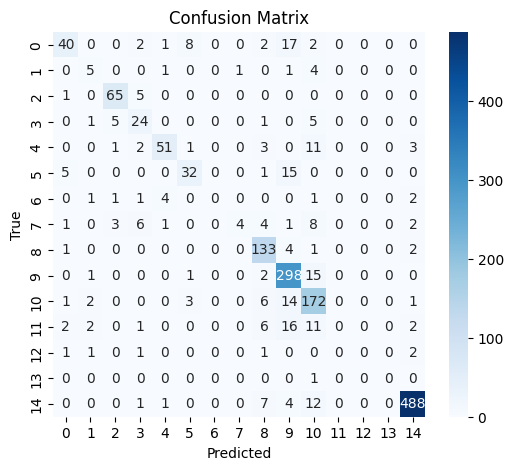

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Training, evaluation, and download complete.


In [ ]:
# ===============================
# train_faster_rcnn_colab.ipynb
# ===============================

# ✅ Section 1: Setup & Install
!pip install torch torchvision albumentations -q
import torch, torchvision
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, roc_auc_score
import seaborn as sns
from tqdm import tqdm

# ✅ Section 2: Define Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

class YoloDataset(Dataset):
    def __init__(self, img_dir, label_dir, is_train=True):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.is_train = is_train
        self.imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
            A.Rotate(limit=15, p=0.3),
            A.Resize(512, 512),
            A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
            ToTensorV2()
        ]) if is_train else A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
            ToTensorV2()
        ])

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        label_path = os.path.join(self.label_dir, self.imgs[idx].replace('.jpg', '.txt').replace('.png', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        boxes, labels = [], []
        with open(label_path) as f:
            for line in f.readlines():
                cls_id, xc, yc, bw, bh = map(float, line.strip().split())
                xmin = (xc - bw / 2) * w
                ymin = (yc - bh / 2) * h
                xmax = (xc + bw / 2) * w
                ymax = (yc + bh / 2) * h
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(int(cls_id) + 1)

        transformed = self.transform(image=img, bboxes=boxes, class_labels=labels)
        img_tensor = transformed['image']
        boxes_tensor = torch.tensor(transformed['bboxes'], dtype=torch.float32)
        labels_tensor = torch.tensor(transformed['class_labels'], dtype=torch.int64)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor
        }

        return img_tensor, target

    def __len__(self):
        return len(self.imgs)


# ✅ Section 3: Model Setup
def get_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def collate_fn(batch):
    return tuple(zip(*batch))

# ✅ Section 4: Paths & DataLoader
train_ds_full = YoloDataset(
    img_dir='/content/train/train/images',
    label_dir='/content/train/train/labels',
    transforms=F.to_tensor
)

val_ds_full = YoloDataset(
    img_dir='/content/valid/valid/images',
    label_dir='/content/valid/valid/labels',
    transforms=F.to_tensor
)

# ⚡ Speed up: Use small subset during debug
train_ds = train_ds_full
val_ds = val_ds_full

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn)

# ✅ Section 5: Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=16).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
num_epochs = 5  # ✅ Use higher for final training

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in tqdm(train_dl):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        running_loss += losses.item()
    lr_scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {running_loss:.4f}")

# ✅ Section 6: Save Model (Locally)
save_dir = '/content/faster_rcnn_output'
os.makedirs(save_dir, exist_ok=True)
model_path = f'{save_dir}/fasterrcnn_model.pth'
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")

# ✅ Section 7: Evaluation (Improved)
model.eval()
model.to(device)

true_labels_all, pred_labels_all = [], []
all_scores_all, all_gt_classes = [], []

with torch.no_grad():
    for img, target in tqdm(val_ds):
        img = img.to(device)
        output = model([img])[0]

        pred_scores = output['scores'].detach().cpu().numpy()
        pred_classes = output['labels'].detach().cpu().numpy()
        gt_classes = target['labels'].cpu().numpy()

        # Take only predictions with high confidence
        conf_mask = pred_scores >= 0.5
        pred_classes_filtered = pred_classes[conf_mask]
        scores_filtered = pred_scores[conf_mask]

        if len(pred_classes_filtered) > 0:
            # For each GT box, assign one prediction (approx.)
            match_count = min(len(gt_classes), len(pred_classes_filtered))
            true_labels_all.extend(gt_classes[:match_count])
            pred_labels_all.extend(pred_classes_filtered[:match_count])
            all_scores_all.extend(scores_filtered[:match_count])
            all_gt_classes.extend(gt_classes[:match_count])

# ✅ Section 8: Metrics
if len(true_labels_all) > 0:
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels_all, pred_labels_all, average='weighted', zero_division=0)
    acc = accuracy_score(true_labels_all, pred_labels_all)
    conf_mat = confusion_matrix(true_labels_all, pred_labels_all)

    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Accuracy:  {acc:.4f}")

    # Confusion Matrix Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC AUC (Binary or single-vs-rest if applicable)
    if len(set(true_labels_all)) == 2:
        roc_auc = roc_auc_score(true_labels_all, all_scores_all)
        print(f"ROC AUC Score: {roc_auc:.4f}")
else:
    print("⚠️ Not enough valid predictions. Metrics skipped.")


# ✅ Section 9: Visualize Predictions
def visualize_predictions(model, dataset, num_samples=5):
    model.eval()
    model.to(device)
    for idx in range(num_samples):
        img, target = dataset[idx]
        with torch.no_grad():
            prediction = model([img.to(device)])[0]
        img_np = img.permute(1, 2, 0).cpu().numpy()
        plt.figure(figsize=(8, 8))
        plt.imshow(img_np)
        for box in prediction['boxes']:
            x1, y1, x2, y2 = box.cpu().numpy()
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                              edgecolor='lime', facecolor='none', linewidth=2))
        plt.title("Predicted Boxes")
        plt.axis('off')
        plt.show()

# ✅ Optional: visualize_predictions(model, val_ds)

# ✅ Section 10: Download Model
from google.colab import files
files.download(model_path)

print("✅ Training, evaluation, and download complete.")
